In [4]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import (
    get_config,
    output_dir,
    default_config,
    get_lattice,
    
)
from misc_utils import read_jsonl_to_df, keep_serializable, column_to
from loguru import logger
from fourier_supervised_cleanroom import (
    fit_fourier_series,
    hadamard_transform,
    keep_largest_n,
    mk_train_test,
    sign_signal,
    sample_from_system,
)

In [21]:
task_id = 8
config = get_config(task_id)
lattice = get_lattice(config["lattice"])

J2 = 1
logger.debug(f"Running {task_id=} {J2=}. Creating system...")
system = HeisenbergJ1J2(
    lattice=lattice, J1=1, J2=J2, use_symmetries=False, spin_inversion=None
)
system.get_eigenstates(1)
amplitude = np.abs(system.get_ground_state())
amplitude_order = np.argsort(amplitude)[::-1]

signal_fn = sign_signal(system)
n_test = config["n_test"]
out = []

for n_train in [2**k for k in range(9, 12)]:

    train_states = system.basis.states[amplitude_order[:n_train]]

    rest_states = np.setdiff1d(
        system.canonical_basis.states,
        train_states,
    )

    test_states = sample_from_system(
        system,
        n_test,
        states_to_sample_from=rest_states,
        sampling_power=0,
        replace=True,
    )

    logger.debug(f"Fitting Fourier series...")
    series = fit_fourier_series(
        train_states,
        signal_fn,
        system.number_spins,
    )
    ground_truth = signal_fn(test_states)
    probs_test = np.abs(system.get_ground_state_coeffs(test_states)) ** 2

    for keep_terms in [2**k for k in range(1, system.number_spins)]:
        logger.debug(f"Keeping {keep_terms=} terms...")

        series_truncated = keep_largest_n(series, keep_terms)
        weight_kept = (series_truncated**2).sum() / (series**2).sum()
        reconstructed_signal = hadamard_transform(series_truncated, inplace=True)
        prediction = np.sign(reconstructed_signal[test_states])
        accuracy = np.mean(prediction == ground_truth)
        overlap = (prediction * ground_truth * probs_test).sum() / probs_test.sum()
        logger.debug(f"{accuracy=}, {overlap=}, {weight_kept=}")
        out.append({
            "n_train": n_train,
            "n_test": n_test,
            "keep_terms": keep_terms,
            "accuracy": accuracy,
            "overlap": overlap,
            "weight_kept": weight_kept,
        })

2023-10-09 19:42:49.419 | DEBUG    | __main__:<module>:6 - Running task_id=8 J2=1. Creating system...
2023-10-09 19:42:49.422 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-10-09 19:42:49.424 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-09 19:42:49.426 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis


2023-10-09 19:42:49.503 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 2704156
2023-10-09 19:42:49.515 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None-10.pickle
2023-10-09 19:42:49.807 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -43.0395889923
2023-10-09 19:42:50.517 | DEBUG    | __main__:<module>:35 - Fitting Fourier series...
2023-10-09 19:42:51.005 | DEBUG    | __main__:<module>:45 - Keeping keep_terms=2 terms...
2023-10-09 19:42:51.950 | DEBUG    | __main__:<module>:53 - accuracy=0.24672, overlap=0.025525310926310746, weight_kept=3.4332275390625e-05
2023-10-09 19:42:51.953 | DEBUG    | __main__:<module>:45 - Keeping keep_terms=4 terms...
2023-10-09 19:42:52.870 | DEBUG    | __main__:<module>:53 - accuracy=0.3111, overlap=0.030221221981144523, weight_kept=6.866455078125e-05
2023-

In [16]:
system

<HeisenbergJ1J2:HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None>

In [23]:
2048 / system.basis.number_states 

0.0007573527562758953

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


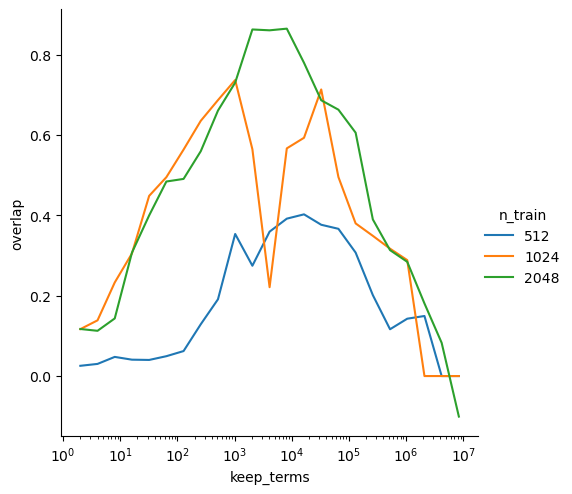

In [22]:
sns.relplot(pd.DataFrame(out).pipe(column_to(str, 'n_train')), x="keep_terms", y="overlap", hue="n_train", kind="line").set(
    xscale="log"
)